# SVHN Digit Classification

This notebook explores classifying house-number digits from the [Street View House Numbers (SVHN)](http://ufldl.stanford.edu/housenumbers/) dataset. It compares several approaches:

1. A baseline MLP classifier on raw pixel features
2. Preprocessing experiments (grayscale conversion, black/white normalization)
3. Dimensionality reduction with PCA
4. An ensemble (voting) of MLPs with different architectures
5. A custom convolutional neural network (CNN) built with PyTorch

This notebook contains the code, results, and enough context to follow along; see [`report.pdf`](./report.pdf) in this repo for the full write-up, discussion, and conclusions.

**Data requirement:** this notebook expects `train_32x32.mat` and `test_32x32.mat` (the "Format 2" cropped-digit `.mat` files from the SVHN site) to be present in `data/`. Download them from the link above.

**Supporting material:** hyperparameter sweeps and alternative approaches that informed the choices in this notebook are in [`appendix.ipynb`](./appendix.ipynb).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from scipy.io import loadmat
from skimage.filters import threshold_otsu
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.ensemble import VotingClassifier

## 1. Load the data

SVHN's cropped-digit format ships as `.mat` files. Labels run 1-10, where `10` represents the digit `0`.

In [2]:
training_data = loadmat("data/train_32x32.mat")
testing_data = loadmat("data/test_32x32.mat")

X_tr_raw = training_data['X']
y_tr = training_data['y'].ravel()
X_te_raw = testing_data['X']
y_te = testing_data['y'].ravel()

print("Train:", X_tr_raw.shape, y_tr.shape)
print("Test: ", X_te_raw.shape, y_te.shape)

Train: (32, 32, 3, 73257) (73257,)
Test:  (32, 32, 3, 26032) (26032,)


Sample images, in color:

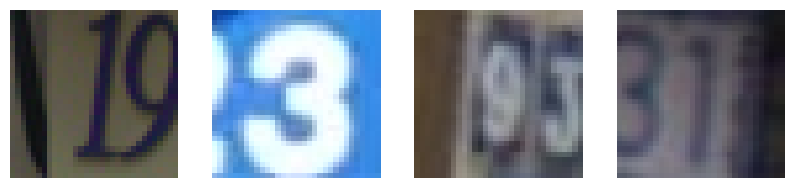

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(10, 8))
for i in range(4):
    axes[i].imshow(X_tr_raw[:, :, :, i * 3])
    axes[i].axis('off')
plt.show()

## 2. Preprocessing

### Grayscale conversion

Converting to grayscale collapses the 3 color channels into a single luminance channel, cutting feature count by 3x.

In [3]:
def greyscale(image):
    """Convert an (H, W, 3, N) RGB image stack to (H, W, N) grayscale using standard luma weights."""
    weights = np.array([0.299, 0.587, 0.114])
    return np.tensordot(image, weights, axes=(2, 0)).astype(np.float64)

X_tr = greyscale(X_tr_raw)
X_te = greyscale(X_te_raw)
print("Grayscale shape:", X_tr.shape, X_te.shape)

Grayscale shape: (32, 32, 73257) (32, 32, 26032)


The same sample images after grayscale conversion:

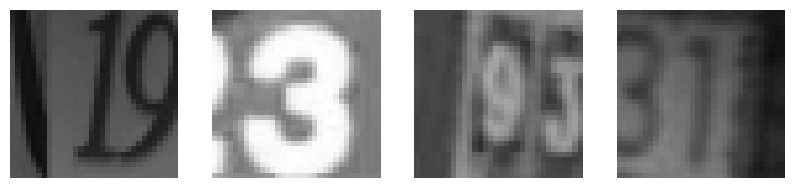

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(10, 8))
for i in range(4):
    axes[i].imshow(X_tr[:, :, i*3], cmap='gray', vmin=0, vmax=255)
    axes[i].axis('off')
plt.show()

### Black/white normalization (experimental)

House numbers are photographed with either light-on-dark or dark-on-light digits. This heuristic looks at the image border to guess the background color and inverts the image so digits are consistently rendered dark-on-light.

In [4]:
def otsu_compare(X, border_width=2, min_std=10):
    X = X.copy()
    num_images = X.shape[2]
    for i in range(num_images):
        top = X[:border_width, :, i].ravel()
        bottom = X[-border_width:, :, i].ravel()
        left = X[:, :border_width, i].ravel()
        right = X[:, -border_width:, i].ravel()
        border = np.concatenate([top, bottom, left, right])
        
        # If border has low variance (mostly same color), then just look at the border's color
        if border.std() < min_std:
            if border.mean() < 128:
                X[:, :, i] = 255 - X[:, :, i]
            continue

        cutoff = threshold_otsu(border.astype(np.float64))
        num_white = (border > cutoff).sum()
        num_black = (border <= cutoff).sum()
        if num_black > num_white:
            X[:, :, i] = 255 - X[:, :, i]
    return X

X_trw_otsu = otsu_compare(X_tr)
X_tew_otsu = otsu_compare(X_te)

The same sample images after normalization via the Otsu method:

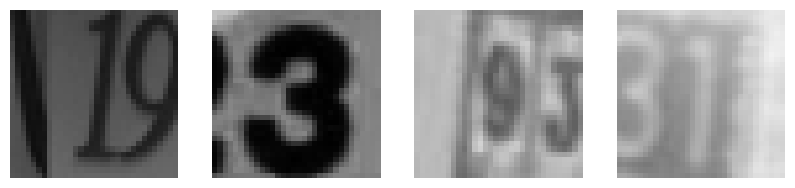

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(10, 8))
for i in range(4):
    axes[i].imshow(X_trw_otsu[:, :, i*3], cmap='gray', vmin=0, vmax=255)
    axes[i].axis('off')
plt.show()

In [5]:
def mean_compare(X, border_width=1, interior_margin=8):
    """Compares the mean brightness of each image's interior to its border.
    """
    X = X.copy()
    num_images = X.shape[2]
    for i in range(num_images):
        top = X[:border_width, :, i].ravel()
        bottom = X[-border_width:, :, i].ravel()
        left = X[:, :border_width, i].ravel()
        right = X[:, -border_width:, i].ravel()
        border = np.concatenate([top, bottom, left, right])

        interior = X[interior_margin:-interior_margin, interior_margin:-interior_margin, i]

        if interior.mean() > border.mean():
            X[:, :, i] = 255 - X[:, :, i]
    return X

X_trw_mean = mean_compare(X_tr)
X_tew_mean = mean_compare(X_te)

The same sample images after normalization via comparison of images' border and interior:

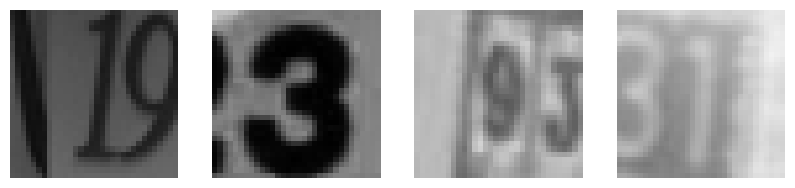

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(10, 8))
for i in range(4):
    axes[i].imshow(X_trw_mean[:, :, i*3], cmap='gray', vmin=0, vmax=255)
    axes[i].axis('off')
plt.show()

Keep a copy of the images in their original 2D shape (`N, 32, 32`) for the CNN section later. 
The next step flattens `X_tr`/`X_te` into 1024-length feature vectors for the MLP/PCA experiments, which a `Conv2d` layer can't consume directly.

In [6]:
X_tr_img = np.transpose(X_tr, (2, 0, 1)).copy()  # (N, 32, 32), still in [0, 255]
X_te_img = np.transpose(X_te, (2, 0, 1)).copy()
X_trw_otsu_img = np.transpose(X_trw_otsu, (2, 0, 1)).copy()
X_tew_otsu_img = np.transpose(X_tew_otsu, (2, 0, 1)).copy()
X_trw_mean_img = np.transpose(X_trw_mean, (2, 0, 1)).copy()
X_tew_mean_img = np.transpose(X_tew_mean, (2, 0, 1)).copy()

## 3. Baseline Multi-Layer Perceptron

### Flatten and normalize

Reshape each 32x32 image into a 1024-length feature vector and scale pixel values to `[0, 1]`.

In [7]:
print("Before:", X_tr.shape, X_te.shape, y_tr.shape, y_te.shape)

X_tr = (X_tr.reshape(1024, X_tr.shape[2]) / 255.0).T
X_te = (X_te.reshape(1024, X_te.shape[2]) / 255.0).T
X_trw_otsu = (X_trw_otsu.reshape(1024, X_trw_otsu.shape[2]) / 255.0).T
X_tew_otsu = (X_tew_otsu.reshape(1024, X_tew_otsu.shape[2]) / 255.0).T
X_trw_mean = (X_trw_mean.reshape(1024, X_trw_mean.shape[2]) / 255.0).T
X_tew_mean = (X_tew_mean.reshape(1024, X_tew_mean.shape[2]) / 255.0).T

print("After: ", X_tr.shape, X_te.shape, y_tr.shape, y_te.shape)

Before: (32, 32, 73257) (32, 32, 26032) (73257,) (26032,)
After:  (73257, 1024) (26032, 1024) (73257,) (26032,)


In [8]:
def train_mlp(X_tr, y_tr, X_te, y_te, title, hidden_layer_sizes, n_epochs=100, patience=10, verbose=False):
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation='relu',
        solver='adam',
        batch_size=256,
        random_state=123,
    )

    classes = np.unique(y_tr)
    train_accs, test_accs = [], []
    best_test_acc = 0
    epochs_no_improve = 0

    for epoch in range(n_epochs):
        if epoch == 0:
            mlp.partial_fit(X_tr, y_tr, classes=classes)
        else:
            mlp.partial_fit(X_tr, y_tr)
        train_acc = mlp.score(X_tr, y_tr)
        test_acc = mlp.score(X_te, y_te)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        if verbose:
            print(f"Epoch {epoch+1}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    plt.plot(range(1, len(train_accs) + 1), train_accs, label='Train Accuracy')
    plt.plot(range(1, len(test_accs) + 1), test_accs, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f"MLP: {title}")
    plt.show()
    return best_test_acc

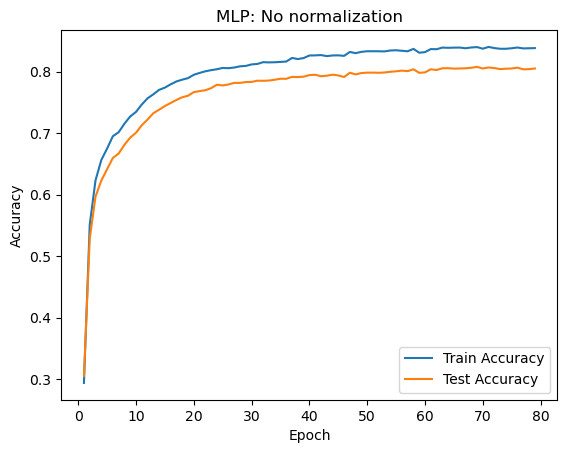

Best test accuracy: 0.8078518746158574


In [9]:
acc = train_mlp(X_tr, y_tr, X_te, y_te, "No normalization", (512,))
print("Best test accuracy:", acc)

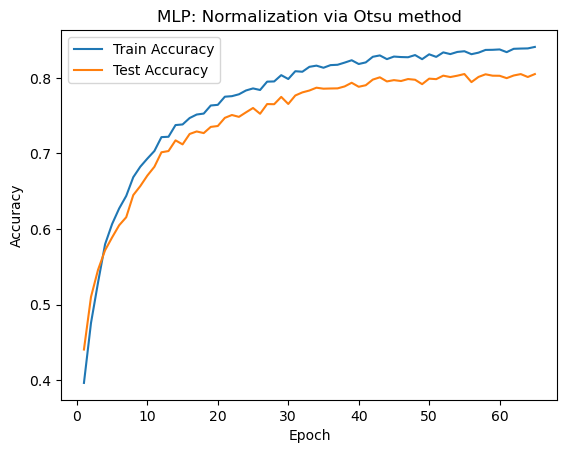

Best test accuracy: 0.8051628764597418


In [10]:
acc = train_mlp(X_trw_otsu, y_tr, X_tew_otsu, y_te, "Normalization via Otsu method", (512,))
print("Best test accuracy:", acc)

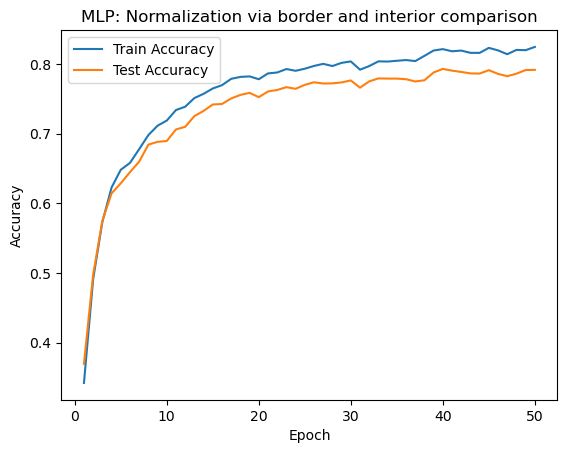

Best test accuracy: 0.7930239704978488


In [12]:
acc = train_mlp(X_trw_mean, y_tr, X_tew_mean, y_te, "Normalization via border and interior comparison", (512,))
print("Best test accuracy:", acc)

## 4. Dimensionality Reduction with Principal Component Analysis

Raw 1024-pixel features are highly redundant. PCA lets us keep most of the variance with far fewer dimensions.

In [20]:
pca = PCA(n_components=0.98)  # keep components explaining 98% of variance
X_tr_pca = pca.fit_transform(X_tr)
X_te_pca = pca.transform(X_te)

print("Original shape:", X_tr.shape)
print("Reduced shape of original data:", X_tr_pca.shape)

Original shape: (73257, 1024)
Reduced shape of original data: (73257, 86)


In [14]:
pca_otsu = PCA(n_components=0.98)
X_trw_otsu_pca = pca_otsu.fit_transform(X_trw_otsu)
X_tew_otsu_pca = pca_otsu.transform(X_tew_otsu)

print("Reduced shape of Otsu method data:", X_trw_otsu_pca.shape)

Reduced shape of Otsu method data: (73257, 84)


In [15]:
pca_mean = PCA(n_components=0.98)
X_trw_mean_pca = pca_mean.fit_transform(X_trw_mean)
X_tew_mean_pca = pca_mean.transform(X_tew_mean)
print("Reduced shape of border vs interior comparison data:", X_trw_mean_pca.shape)

Reduced shape of border vs interior comparison data: (73257, 84)


An MLP trained directly on the PCA-reduced features:

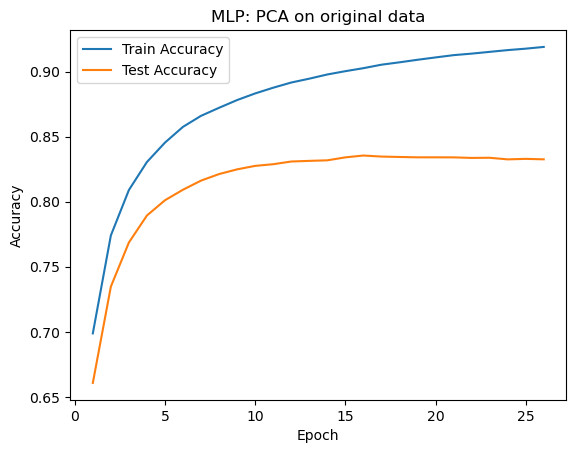

Best test accuracy: 0.8355101413644745


In [23]:
acc = train_mlp(X_tr_pca, y_tr, X_te_pca, y_te, "PCA on original data", (128, 64))
print("Best test accuracy:", acc)

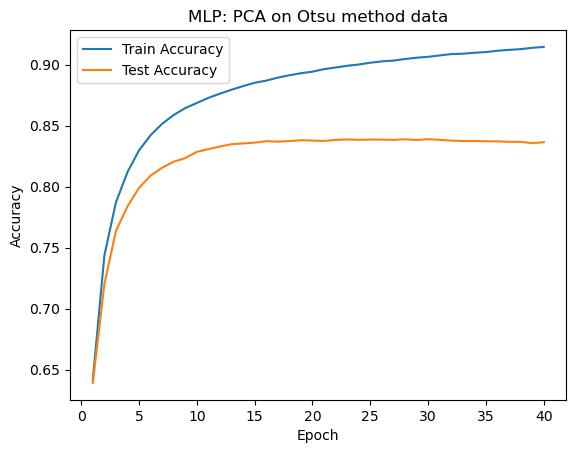

Best test accuracy: 0.8388905961893055


In [24]:
acc = train_mlp(X_trw_otsu_pca, y_tr, X_tew_otsu_pca, y_te, "PCA on Otsu method data", (128, 64))
print("Best test accuracy:", acc)

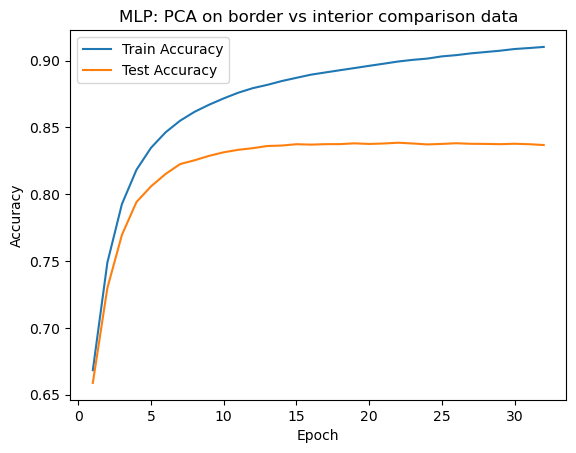

Best test accuracy: 0.8385064535955746


In [25]:
acc = train_mlp(X_trw_mean_pca, y_tr, X_tew_mean_pca, y_te, "PCA on border vs interior comparison data", (128, 64))
print("Best test accuracy:", acc)

## 5. Ensembling MLPs

Three MLPs with different hidden-layer architectures and different random seeds, combined via soft voting. Architecture and seed diversity give each member a genuinely different inductive bias and starting point, so their errors are more likely to be complementary than correlated.

A feature-splitting ensemble and a mixed-algorithm (MLP + random forest + SVM) ensemble were also tried and are in the appendix, but they performed worse.

In [28]:
mlp1 = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', early_stopping=True,
                      batch_size=256, random_state=1, solver='adam', max_iter=500, alpha=0.01)
mlp2 = MLPClassifier(hidden_layer_sizes=(128,), activation='relu', early_stopping=True,
                      batch_size=256, random_state=2, solver='adam', max_iter=500, alpha=0.01)
mlp3 = MLPClassifier(hidden_layer_sizes=(64, 32, 16), activation='relu', early_stopping=True,
                      batch_size=256, random_state=3, solver='adam', max_iter=500, alpha=0.01)

voting_clf_standard = VotingClassifier(
    estimators=[('mlp1', mlp1), ('mlp2', mlp2), ('mlp3', mlp3)],
    voting='soft'
)
voting_clf_standard.fit(X_tr_pca, y_tr)

print("Standard ensemble train accuracy:", voting_clf_standard.score(X_tr_pca, y_tr))
print("Standard ensemble test accuracy: ", voting_clf_standard.score(X_te_pca, y_te))

# for comparison: each individual member's own test accuracy
for name, model in voting_clf_standard.named_estimators_.items():
    encoded_acc = model.score(X_te_pca, voting_clf_standard.le_.transform(y_te))
    print(f"{name} test accuracy: {encoded_acc:.4f}")

Standard ensemble train accuracy: 0.9219050739178508
Standard ensemble test accuracy:  0.8534496004917025
mlp1 test accuracy: 0.8351
mlp2 test accuracy: 0.8404
mlp3 test accuracy: 0.8117


## 6. Convolutional Neural Network

A minimal configurable CNN built directly on `torch.nn.Module` (`SimpleConvNet`), trained on the un-flattened grayscale images. Architecture (number/size of conv layers, kernel sizes, pooling), regularization (weight decay, dropout), and training behavior (early stopping with best-weight restoration) are all configurable via constructor arguments, so the same class is reused throughout this section and the appendix rather than duplicated per experiment.

`train_cnn` is a thin wrapper: build a `SimpleConvNet`, fit it with early stopping against the test set, plot train/test accuracy per epoch, and return the best test accuracy.

In [7]:
def get_list_or_num_param_val(param, index):
    """Allow a hyperparameter to be given either as a single value (used for every layer)
    or a per-layer list/tuple."""
    if type(param) not in (list, tuple):
        return param
    return param[index] if len(param) > index else param[0]


class SimpleConvNet(torch.nn.Module):
    def __init__(self, numChannels=1, classes=10, channel_sizes=(32, 64), kernel_sizes=((3, 3),),
                 strides=(1,), conv_paddings=(1,), pool_kernels=((2, 2),), pool_strides=(2,),
                 pool_paddings=(0,), fully_connected_features=128, dropout_rate=0.0, device=None, **hyperparameters):
        super().__init__()
        if device is None:
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.device = torch.device(device)

        # we store our operations in lists: convolutional layer -> pool -> ...
        self.conv_ = list()
        self.pool_ = list()
        self.drop_ = list()
        for i in range(len(channel_sizes)):
            c = torch.nn.Conv2d(in_channels=numChannels if i == 0 else channel_sizes[i - 1],
                                 out_channels=channel_sizes[i],
                                 kernel_size=get_list_or_num_param_val(kernel_sizes, i),
                                 stride=get_list_or_num_param_val(strides, i),
                                 padding=get_list_or_num_param_val(conv_paddings, i))
            p = torch.nn.MaxPool2d(kernel_size=get_list_or_num_param_val(pool_kernels, i),
                                    stride=get_list_or_num_param_val(pool_strides, i),
                                    padding=get_list_or_num_param_val(pool_paddings, i))
            d = torch.nn.Dropout2d(p=get_list_or_num_param_val(dropout_rate, i))
            self.add_convolution(c, p, d)

        # first fully connected layer - LazyLinear infers correct in_features on first pass
        self.fc1 = torch.nn.LazyLinear(out_features=fully_connected_features)
        self.fc1_drop = torch.nn.Dropout(p=get_list_or_num_param_val(dropout_rate, -1))
        self.fc2 = torch.nn.Linear(in_features=fully_connected_features, out_features=classes)
        self.logSoftmax = torch.nn.LogSoftmax(dim=1)
        self.set_hyperparameters(**hyperparameters)
        self.to(self.device)

    def add_convolution(self, conv, pool, dropout):
        self.conv_.append(conv)
        self.pool_.append(pool)
        self.drop_.append(dropout)
        setattr(self, f"c{len(self.pool_)}", conv)
        setattr(self, f"p{len(self.pool_)}", pool)
        setattr(self, f"d{len(self.pool_)}", dropout)

    def set_hyperparameters(self, learning_rate_init=1e-3, batch_size=64, max_iter=100,
                             momentum=0.9, alpha=.001, activation='relu', **more):
        self.lr = learning_rate_init
        self.batch_size = batch_size
        self.epochs = max_iter
        self.momentum = momentum
        self.alpha = alpha
        # reference: machinelearningmastery.com/activation-functions-in-pytorch/
        if activation == 'relu':
            self.activation_ = torch.nn.ReLU()
        elif activation == 'logistic':
            self.activation_ = torch.nn.Sigmoid()
        elif activation == 'tanh':
            self.activation_ = torch.nn.Tanh()
        elif activation == 'leakyrelu':
            self.activation_ = torch.nn.LeakyReLU()
        else:
            # any other activation function. See: https://pytorch.org/docs/stable/nn.html
            self.activation_ = activation
        if more:
            print("WARNING - unrecognized CNN hyperparameters:", ",".join(more.keys()))
        return self

    def forward(self, X):
        """Compute NN forward pass and output class probabilities (as tensor)."""
        for conv, pool, drop in zip(self.conv_, self.pool_, self.drop_):
            X = drop(pool(self.activation_(conv(X))))
        X_flat = torch.flatten(X, 1)
        X = self.fc1_drop(self.activation_(self.fc1(X_flat)))
        X = self.fc2(X)
        return self.logSoftmax(X)

    def predict_prob(self, X, batch_size=512):
        self.eval()
        X = torch.Tensor(X).unsqueeze(1)
        outputs = []
        with torch.no_grad():
            for i in range(0, X.shape[0], batch_size):
                batch = X[i:i + batch_size].to(self.device)
                outputs.append(self.forward(batch).cpu())
        return torch.cat(outputs, dim=0).numpy()

    def predict(self, X, batch_size=512):
        results = self.predict_prob(X, batch_size=batch_size)
        return np.argmax(results, axis=1)

    def fit(self, X, y, optimizer='adam', X_te=None, y_te=None, early_stopping=False, 
            patience=10, restore_best_weights=True):
        if early_stopping and (X_te is None or y_te is None):
            raise ValueError("early_stopping=True requires X_val and y_val to monitor")

        self.classes_ = np.unique(y)
        self.train_acc_, self.test_acc_ = list(), list()
        lossFn = torch.nn.NLLLoss()
        X = torch.Tensor(X)
        y = torch.Tensor(y).long()
        train_data = torch.utils.data.TensorDataset(X.unsqueeze(1), y)
        trainDataLoader = torch.utils.data.DataLoader(
            train_data, shuffle=True, batch_size=self.batch_size,
            pin_memory=(self.device.type == 'cuda')
        )
        if optimizer == 'adam':
            optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.alpha)

        best_test_acc = 0
        best_state = None
        epochs_no_improve = 0

        for epoch in range(self.epochs):
            self.train()
            for (x, y_batch) in trainDataLoader:
                x = x.to(self.device, non_blocking=True)
                y_batch = y_batch.to(self.device, non_blocking=True)
                optimizer.zero_grad()
                pred = self(x)
                loss = lossFn(pred, y_batch)
                loss.backward()
                optimizer.step()

            if X_te is not None and y_te is not None:
                train_pred = self.predict(X.numpy())
                test_pred = self.predict(X_te)
                test_acc = (test_pred == y_te).mean()
                self.train_acc_.append((train_pred == y.numpy()).mean())
                self.test_acc_.append(test_acc)
                
                if early_stopping:
                    if test_acc > best_test_acc:
                        best_test_acc = test_acc
                        epochs_no_improve = 0
                        if restore_best_weights:
                            best_state = {k: v.clone() for k, v in self.state_dict().items()}
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= patience:
                            break

        if early_stopping and restore_best_weights and best_state is not None:
            self.load_state_dict(best_state)


def train_cnn(X_tr, y_tr, X_te, y_te, title, n_epochs=100, patience=10, batch_size=512, device=None, **cnn_kwargs):
    cnn = SimpleConvNet(device=device, max_iter=n_epochs, batch_size=batch_size, **cnn_kwargs)
    cnn.fit(
        X_tr / 255.0, y_tr - 1,
        X_te=X_te / 255.0, y_te=y_te - 1,
        early_stopping=True, patience=patience
    )
    best_test_acc = max(cnn.test_acc_)

    epochs_range = range(1, len(cnn.train_acc_) + 1)
    plt.plot(epochs_range, cnn.train_acc_, label='Train Accuracy')
    plt.plot(epochs_range, cnn.test_acc_, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f"CNN: {title}")
    plt.show()

    return best_test_acc

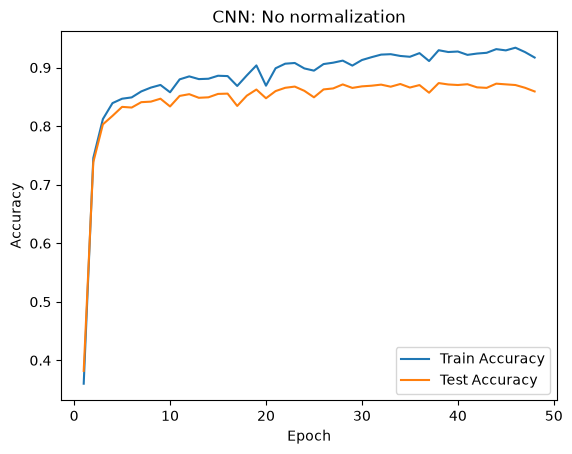

Best test accuracy: 0.8735786724031961


In [31]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="No normalization")
print(f"Best test accuracy: {best_acc}")

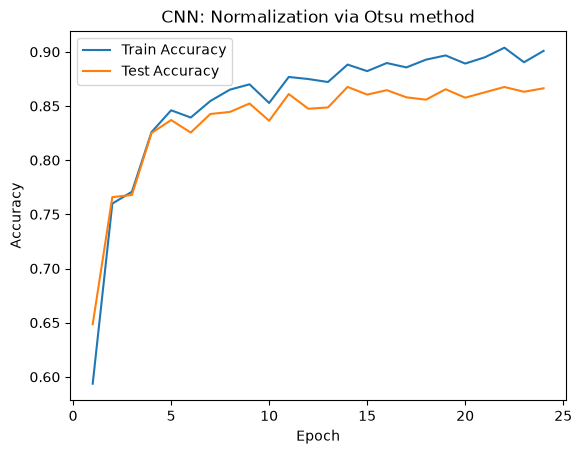

Best test accuracy: 0.8676244622003688


In [74]:
best_acc = train_cnn(X_trw_otsu_img, y_tr, X_tew_otsu_img, y_te, title="Normalization via Otsu method")
print(f"Best test accuracy: {best_acc}")

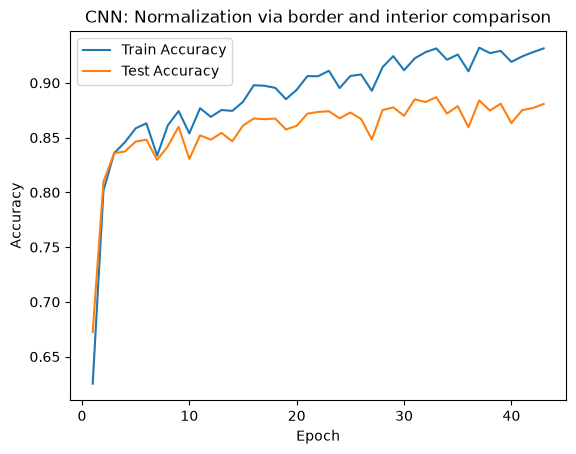

Best test accuracy: 0.8869468346650277


In [24]:
best_acc = train_cnn(X_trw_mean_img, y_tr, X_tew_mean_img, y_te, title="Normalization via border and interior comparison")
print(f"Best test accuracy: {best_acc}")

### Best-Performing CNN

The configuration below combines the best-performing choices from the comparisons above and the sweeps in the appendix: border/interior comparison normalization, `alpha=1e-3`, `channel_sizes=(32, 64, 128)`, and a per-layer dropout schedule (heavier dropout on the fully-connected layer than on the conv layers).

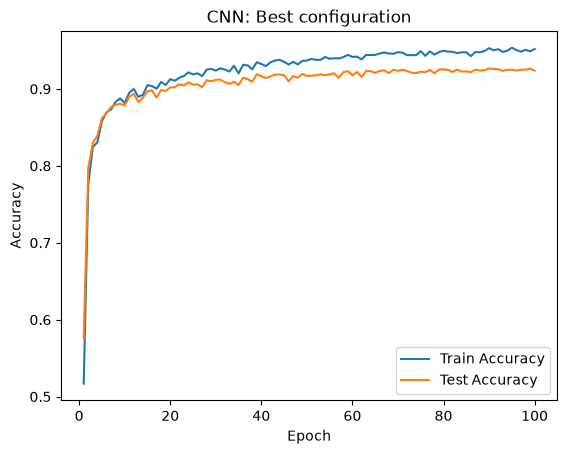

Best test accuracy: 0.9265135218192994


In [9]:
best_acc = train_cnn(X_trw_mean_img, y_tr, X_tew_mean_img, y_te, title="Best configuration", alpha=1e-3, channel_sizes=(32, 64, 128), dropout_rate=(0, 0, 0.5, 0))
print(f"Best test accuracy: {best_acc}")

## Results Summary

| Model | Best test accuracy |
|---|---|
| MLP, raw pixels | 0.8079 |
| MLP, PCA-reduced features | 0.8389 |
| MLP ensemble (architecture + seed diversity) | 0.8534 |
| CNN, final configuration | 0.9265 |

Full discussion of these results, including why the architecture/normalization choices above were made and what the appendix's sweeps ruled out, is in [`report.pdf`](./report.pdf).

## Appendix

Hyperparameter sweeps and alternative approaches that informed the choices above, such as preprocessing parameter tuning, MLP/CNN architecture comparisons, weight decay and dropout sweeps, and the feature-splitting / mixed-algorithm ensembling experiments that were tried and set aside, are in **[appendix.ipynb](./appendix.ipynb)**.